In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.graphics.plot_grids import scatter_ellipse

In [5]:
data_raw = sns.load_dataset('iris')
labels = ['Sepal length','Sepal width',
          'Petal length','Petal width']

/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_54338/1707589688.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


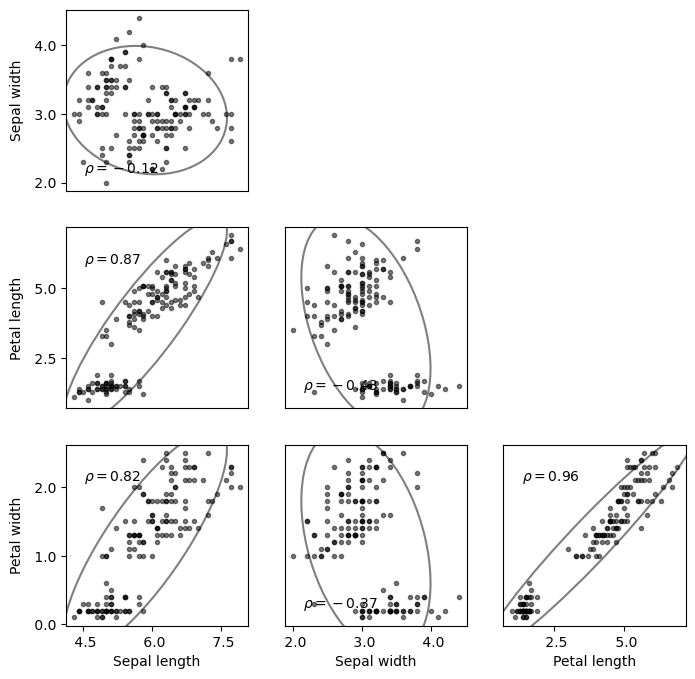

In [9]:
fig = plt.figure(figsize = (8,8))
scatter_ellipse(data_raw.iloc[:,:-1], #第一个:表示所有行 :-1表示除了最后一列的所有列
                varnames = labels,fig = fig)
fig.show()

/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_54338/1131008330.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


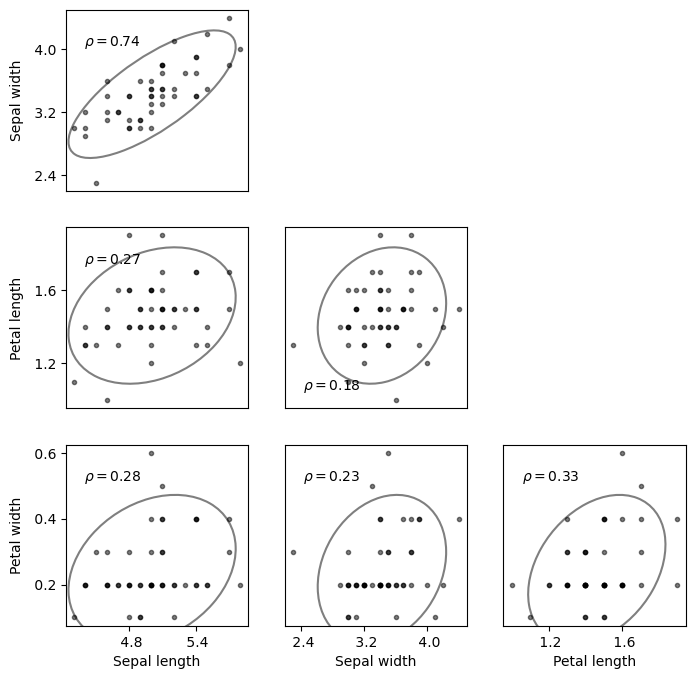

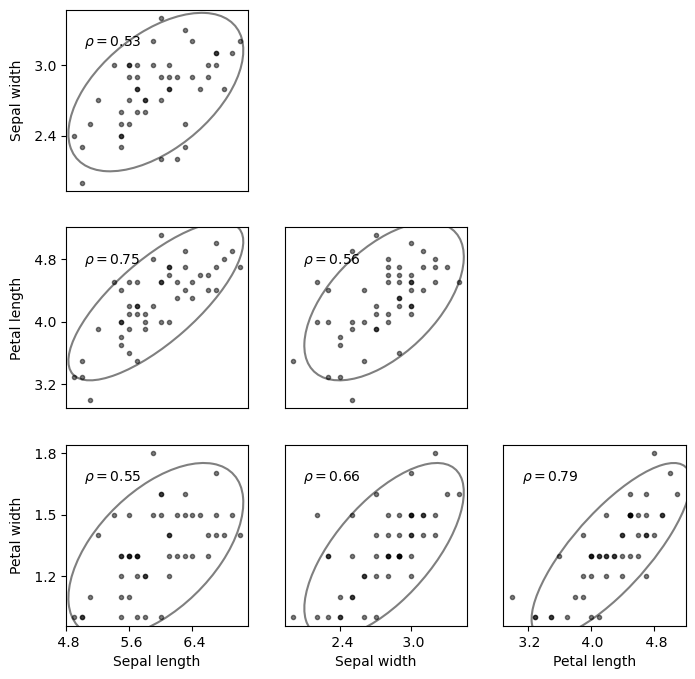

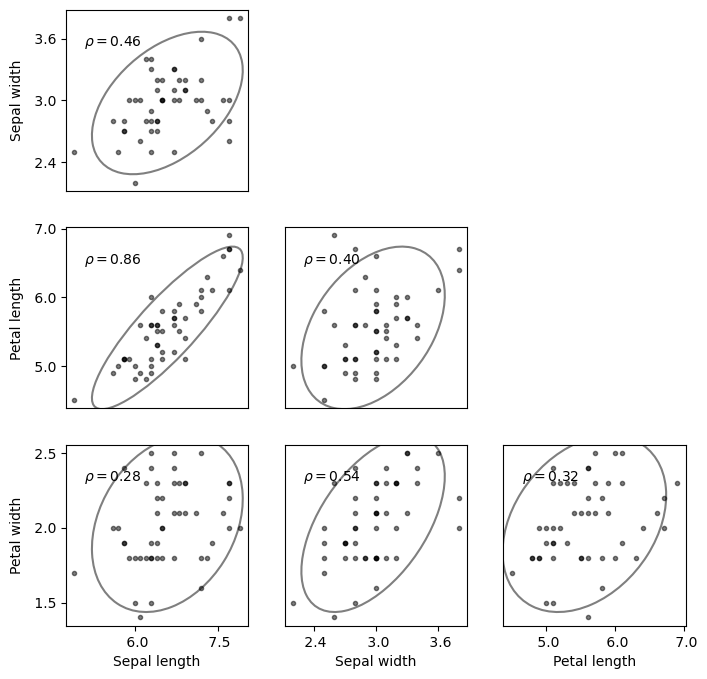

In [17]:
#单个字母s为species的缩写, 提取所有不重复类别附到s_idx上
#提取规则:先提取出species这一列,使用.unique提取出所有不重复的值
#不是迭代器,直接提出来交给for进行循环
for s_idx in data_raw.species.unique():
    #生成布尔数组选出当前物种的数据使用的是[]中的布尔条件 loc表示筛选 iloc表示删除最后一列
    #loc=location,表示按标签筛选 iloc = integer location 按位置索引数据,所有行,去掉最后列
    data = data_raw.loc[data_raw.species == s_idx].iloc[:,:-1]
    fig = plt.figure(figsize = (8,8))
    #这里根据列的顺序匹配标签,之前的-1已经将种类去列去掉列
    #根据已经存在的4个特征列做两辆组合画图
    scatter_ellipse(data,varnames=labels,fig=fig)

fig.show()

In [521]:
import numpy as np
#打包成api方便用户调用
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [551]:
num = 50
np.random.seed(1000)
#生成范围内指定个数的均匀分布浮点数 单词意思表示均匀的一致的
x_data = np.random.uniform(0,10,num)
#服从正太分布的均值0标准差为1的浮点数 按照正态分布概率随机抽取
y_data = 0.5*x_data + 1 + np.random.normal(0,1,num)
#按照列拼接成二维数组
data = np.column_stack([x_data,y_data])

In [553]:
#添加常数列
#添加常数为1的列在左侧,为了计算截距项并将值添加在此 变为二维矩阵的过程中,x作为列数据排列,在左侧添加为1的列,表示截距,截距数值必须全部一样
X = sm.add_constant(x_data)

In [555]:
#创建一元线性回归
#必须为X,二维数据.正确拟合截距+斜率
#如果X为x_data 将会默认拟合过原点的线,截距为0
#这一步表示准备好数学公式和数据
#建立模型 不计算,只准备 定义要做什么
model = sm.OLS(y_data,X)

In [557]:
#拟合模型
#真正计算求出直线
#拟合数据(真正求解参数) 进行实际数学运算 具体怎么做,得出结果
results = model.fit()

In [559]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     92.69
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           8.65e-13
Time:                        17:05:18   Log-Likelihood:                -77.235
No. Observations:                  50   AIC:                             158.5
Df Residuals:                      48   BIC:                             162.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1038      0.291      3.792      0.0

In [561]:
#预测
x_array = np.linspace(0,10,101)
#斜率乘以x的一维数组+截距
predicted = results.params[1] * x_array + results.params[0]

(-2.0, 8.0)

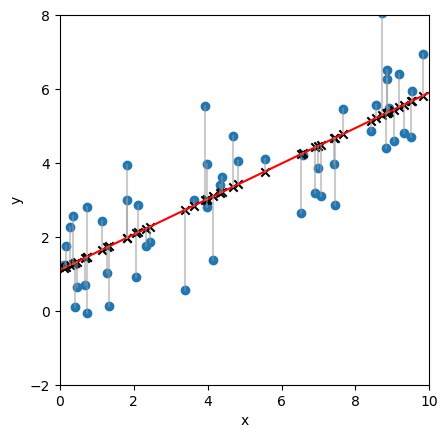

In [563]:
fig,ax = plt.subplots()
#样本值
ax.scatter(x_data,y_data)
#预测值
ax.scatter(x_data,results.fittedvalues,
           color = 'k' , marker = 'x')
#绘制预测线(回归线)
ax.plot(x_array,predicted,
        color = 'r')
#x vs. 拟合值  的成对数组
data_=np.column_stack([x_data,results.fittedvalues])

#误差线(残差线)
#分开i和j是因为需要两组x和y坐标,根据两个元组中的第一层索引顺序对应xy值
ax.plot(([i for (i,j) in data_],[i for (i,j) in data]),
        ([j for (i,j) in data_],[j for (i,j) in data]),
        c = [0.6,0.6,0.6],alpha = 0.5)#?

ax.set_xlabel('x');ax.set_ylabel('y')
ax.set_aspect('equal',adjustable = 'box')
ax.set_xlim(0,10);ax.set_ylim(-2,8)

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#从网站拉取数据工具
import pandas_datareader as pdr
#seaborn绘图工具是matplot的扩展
import seaborn as sns
#导入主成分析模块
import statsmodels.multivariate.pca as pca

In [60]:
df = pdr.data.DataReader(['DGS6MO','DGS1',
                          'DGS2','DGS5',
                          'DGS7','DGS10',
                          'DGS20','DGS30'],
                         #从FRED抓取数据
                         data_source = 'fred',
                         start = '01-01-2022',
                         end = '12-31-2022')
#去除nan值
df = df.dropna()

In [62]:
#修改数据帧列标签
df = df.rename(columns={'DGS6MO':'0.5 yr',
                        'DGS1':'1 yr',
                        'DGS2':'2 yr',
                        'DGS5':'5 yr',
                        'DGS7':'7 yr',
                        'DGS10':'10 yr',
                        'DGS20':'20 yr',
                        'DGS30':'30 yr'})

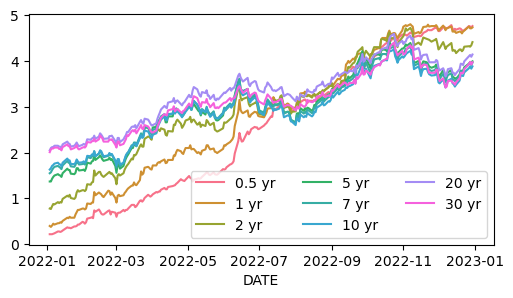

In [78]:
#绘制走势
fig,ax = plt.subplots(figsize = (6,3))
#绘图数据内容的线条样式,颜色   控制线条
sns.lineplot(df,markers = False,dashes=False,#绘制实线
             #配置线条颜色方案
            palette = 'husl',ax=ax)
#调整整个图表的外观,图例,坐标轴等  控制图框
#绘制图例,放在左下角,排成3列
ax.legend(loc = 'lower right',ncol=3)

In [80]:
#计算日收益 每天的值相较于前一天的利率的差值 (利率单位为百分比,但是如果百分比上升或下降,都代表有一定的百分比差值)
#日收益率为 今天的利率-昨天的利率的值 / 昨天的利率   这里利率就是资产价格
X_df = df.pct_change()#公式名称叫相对变化比例
X_df = X_df.dropna()

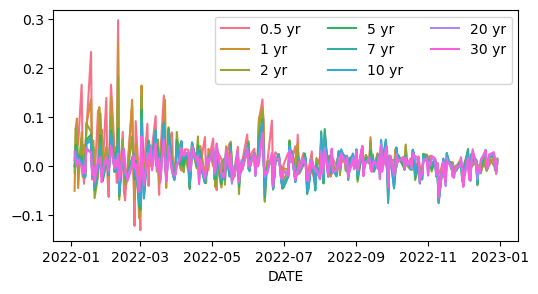

In [86]:
fig,ax = plt.subplots(figsize = (6,3))
sns.lineplot(X_df,markers = False,
             dashes=False,palette='husl',ax=ax)
ax.legend(loc='upper right',ncol=3)

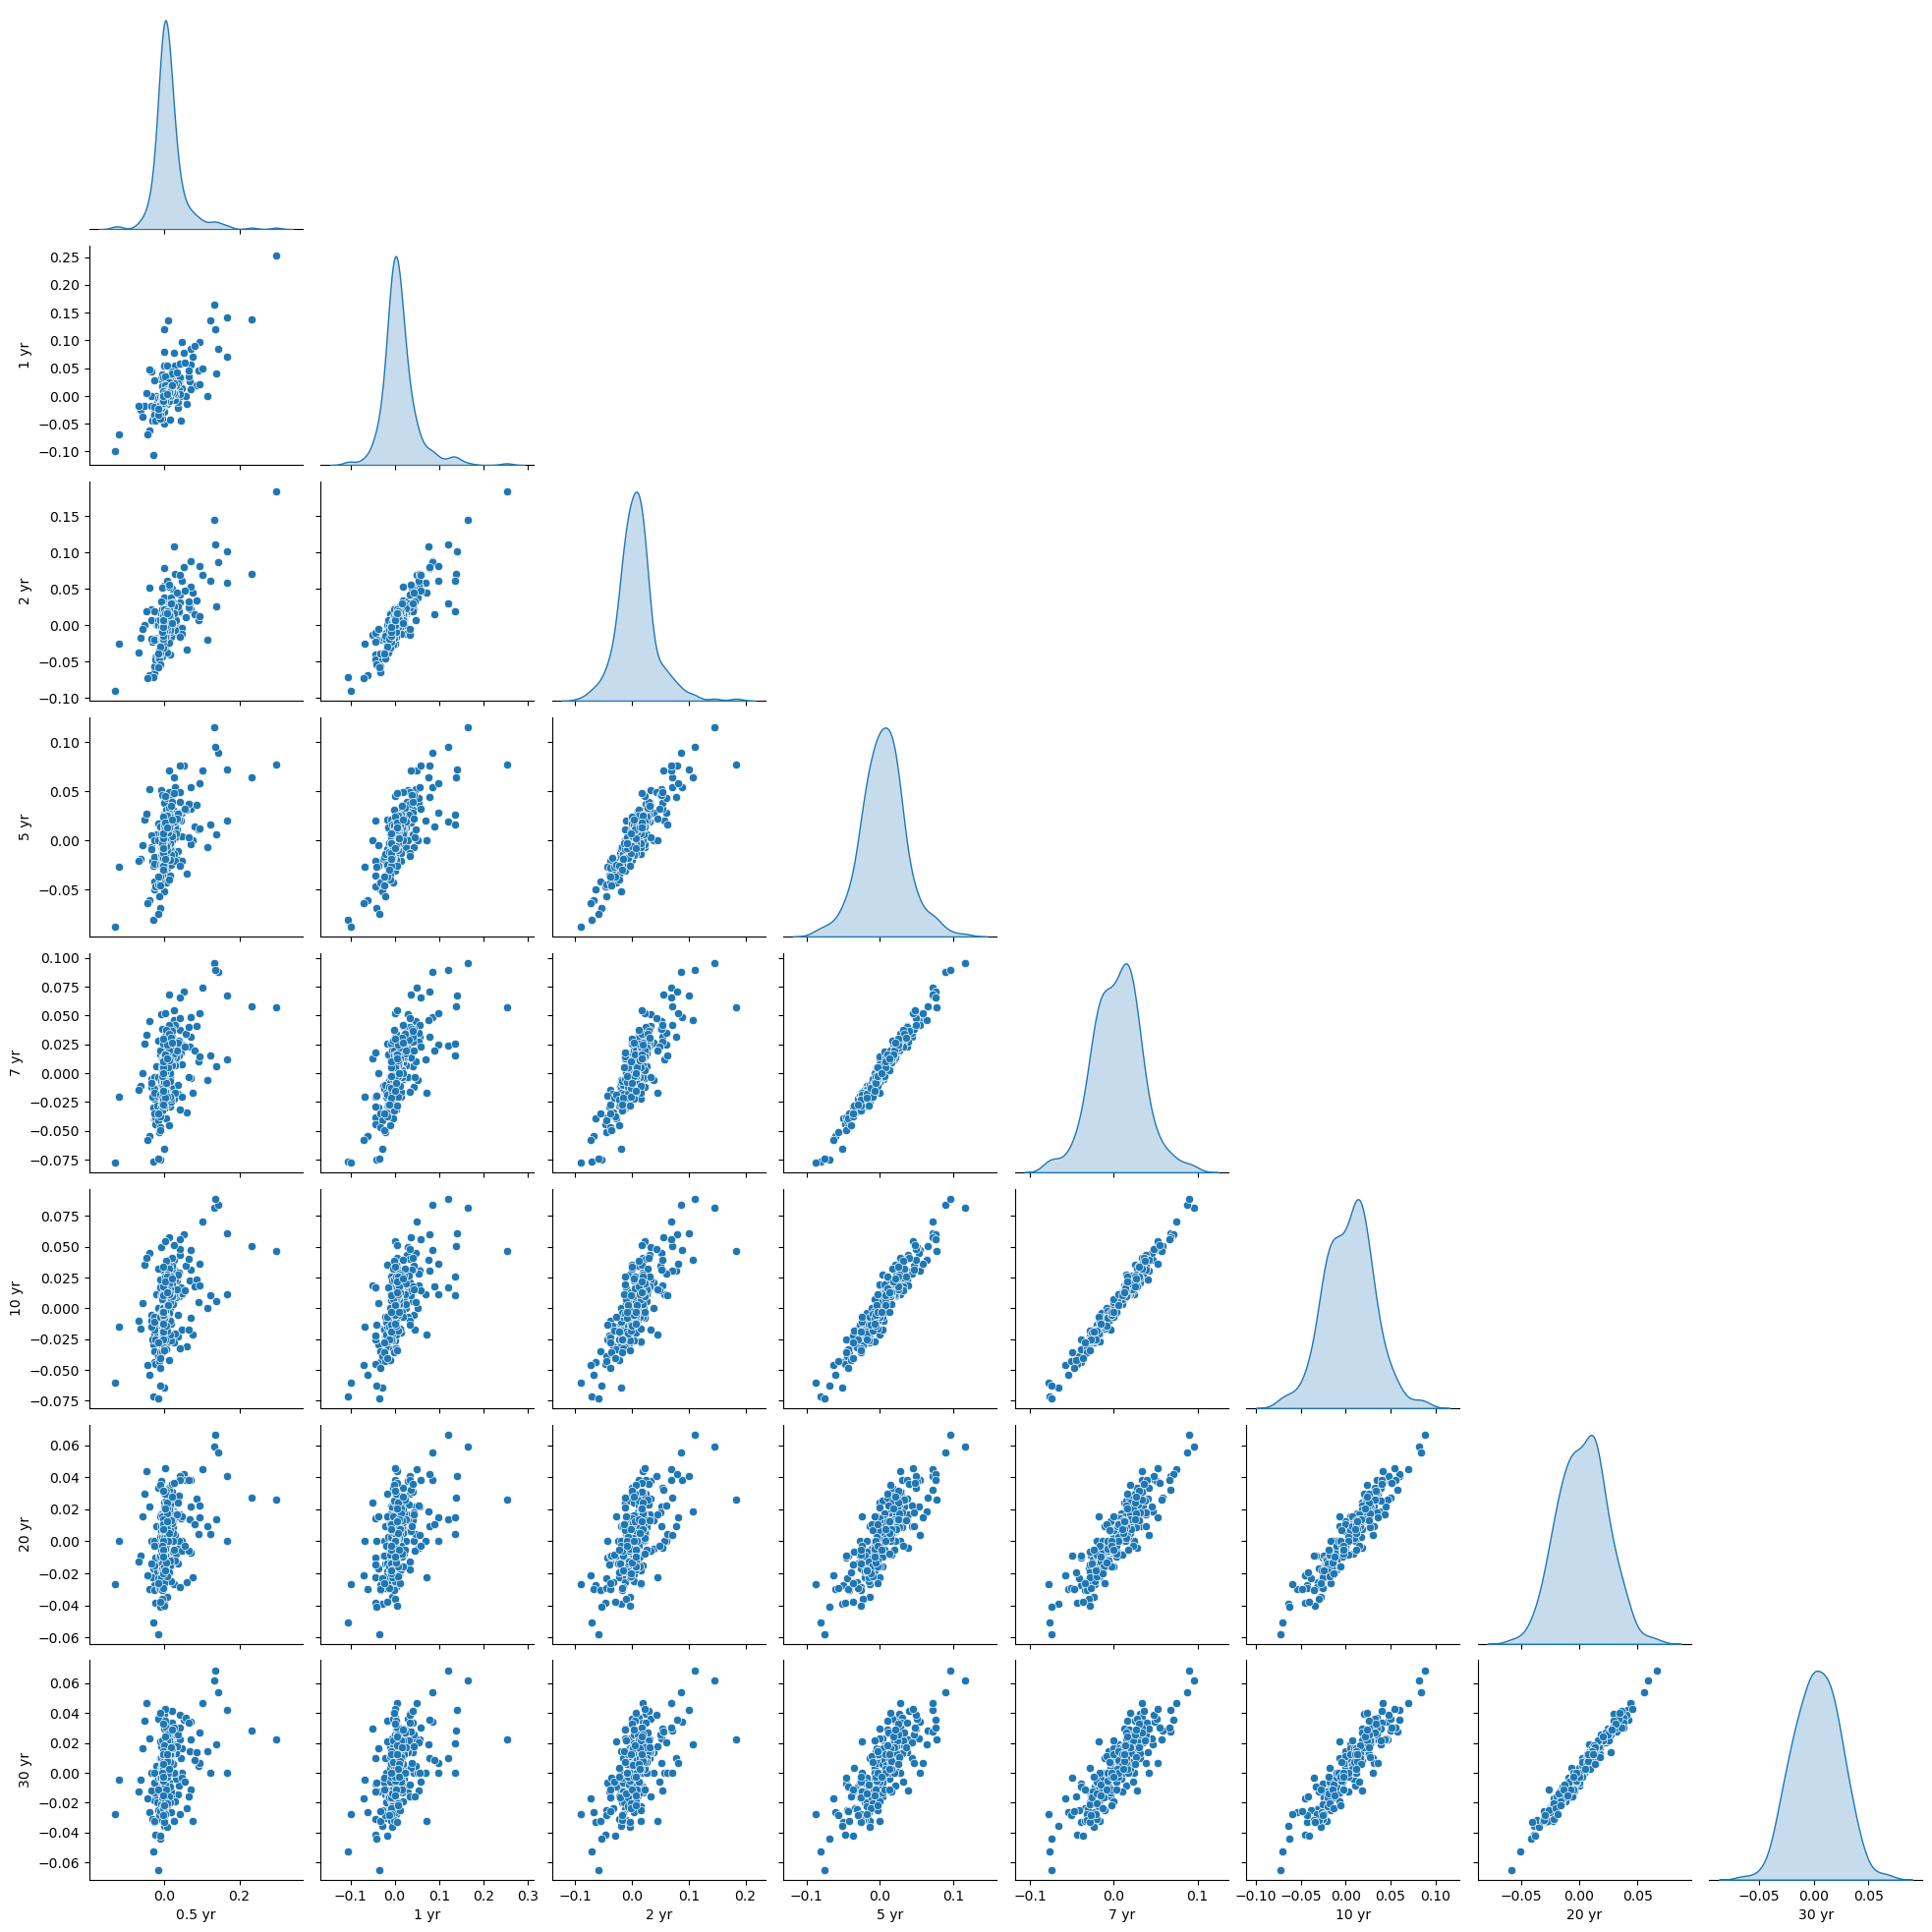

In [92]:
sns.pairplot(X_df,corner = True,diag_kind = 'kde')
#对角线默认为每个变量的直方图  这里改为核密度估计

In [96]:
C = X_df.corr() #相关系数矩阵

<Axes: >

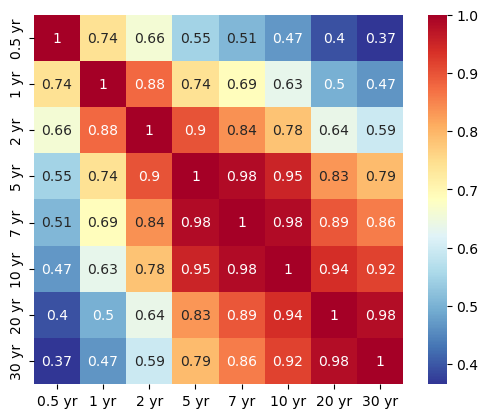

In [100]:
fig,ax = plt.subplots()
sns.heatmap(C,ax = ax,
            annot = True,
            cmap = 'RdYlBu_r',
            square = True)

In [160]:
#完成主成分析
#ncomp参数返回主成分数量,默认返回与原数据特征数一致的主成分数量
#standerdize,指定是否标准化 True表示对原始数据相关系数矩阵进行特征值分解,完成主成分析运算
#dmean指定是否去均值 默认去均值
#method默认为'svd' 奇异值分解进行主成分析 method为'eig代表利用特征值分解完成PCA
pca_model = pca.PCA(X_df,standardize=True)

In [162]:
#特征值从小到大排列
variance_V = pca_model.eigenvals

In [164]:
explained_var_ratio = variance_V/variance_V.sum()

In [166]:
PC_range = np.arange(len(variance_V)) + 1

In [168]:
labels = ['$PC_' + str(index) +'$' for index in PC_range]

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_54338/2818299499.py:4: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel('Eigen value $\lambda$ (PC variance)',color = 'b')


(0.9, 8.1)

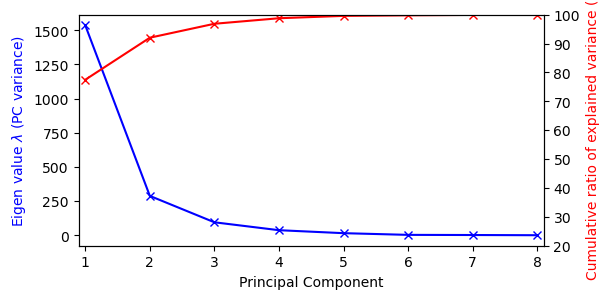

In [176]:
fig,ax1 = plt.subplots(figsize = (6,3))
ax1.plot(PC_range,variance_V,'b',marker = 'x')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigen value $\lambda$ (PC variance)',color = 'b')
ax.set_ylim(0,1600);ax1.set_xticks(PC_range)

ax2 = ax1.twinx()#增加y轴右侧的对象 twin表示双胞胎,x表示共用x轴但生成新的y轴
#cumsum表示累加函数
ax2.plot(PC_range,np.cumsum(explained_var_ratio)*100,'r',marker='x')
ax2.set_ylabel('Cumulative ratio of explained variance (%)',color = 'r')
ax2.set_ylim(20,100)
ax2.set_xlim(PC_range.min() -0.1,PC_range.max() +0.1)

In [178]:
loading = pca_model.loadings[['comp_0','comp_1','comp_2']] #提取自动命名的主成分 从大到小排列

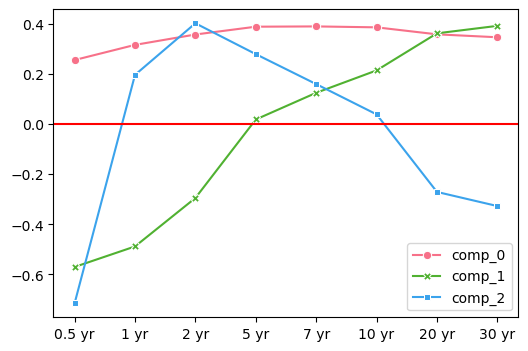

In [182]:
fig,ax = plt.subplots(figsize = (6,4))
sns.lineplot(data = loading,
            markers = True,dashes = False,palette = 'husl')
plt.axhline(y = 0,color = 'r',linestyle = '-')

In [186]:
#开始还原数据
X_df_ = pca_model.project(3)

In [188]:
#原始数据vs还原图

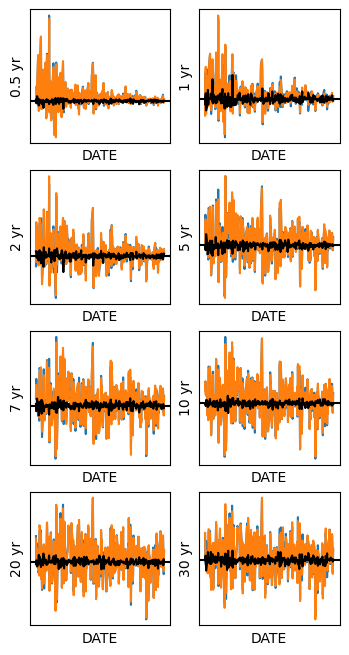

In [196]:
fig,axes = plt.subplots(4,2,figsize = (4,8))
axes = axes.flatten()#axes是图像列表,有8个ax

for col_idx,ax_idx in zip(list(X_df_.columns),axes): #这里每次在axes中穿入一个ax
    sns.lineplot(X_df_[col_idx],ax = ax_idx)
    sns.lineplot(X_df[col_idx],ax = ax_idx)
    sns.lineplot(X_df[col_idx] - X_df_[col_idx],c = 'k',ax = ax_idx)
    ax_idx.set_xticks([]);ax_idx.set_yticks([])
    ax_idx.axhline(y = 0,c = 'k')

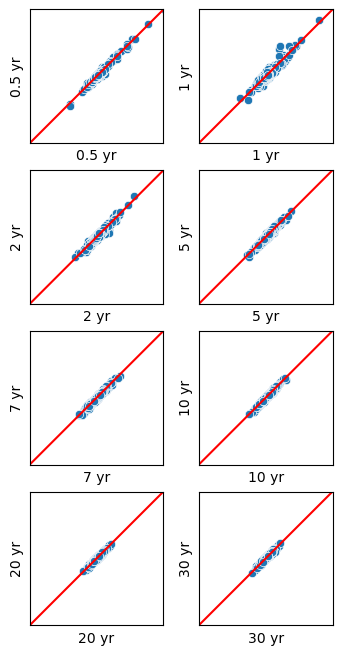

In [200]:
fig,axes = plt.subplots(4,2,figsize = (4,8))
axes = axes.flatten()

for col_idx,ax_idx in zip(list(X_df_.columns),axes):
    sns.scatterplot(x = X_df_[col_idx],
                    y = X_df[col_idx],
                    ax = ax_idx)
    ax_idx.plot([-0.3,0.3],[-0.3,0.3],c = 'r')
    ax_idx.set_aspect('equal',adjustable = 'box')
    ax_idx.set_xticks([]);ax_idx.set_yticks([])
    ax_idx.set_xlim(-0.3,0.3);ax_idx.set_ylim(-0.3,0.3)

In [364]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

In [439]:
iris = load_iris()
y = iris.target #提取标签,0,1,2分别对应三种花 数字是自带的,不是生成的
X_df = pd.DataFrame(iris.data) #降numpy转化为pd数据帧
X1_df = X_df.iloc[:,0] #提取第0列

In [441]:
#创建可视化函数
def visualize(x1,pdf,color):
    fig,ax = plt.subplots(figsize = (8,3))
    #两条曲线之间填充颜色
    ax.fill_between(x1,pdf,facecolor = color ,alpha = 0.2)
    ax.plot(x1,pdf,color = color)

    ax.set_ylabel('PDF')
    ax.set_xlabel('Sepal lengeh, $x_1$')

In [443]:
#创建对象,建模不计算,输入为单一变量数据  用api导入的
KDE = sm.nonparametric.KDEUnivariate(X1_df)
#调整带宽
KDE.fit(bw = 0.1)

In [445]:
x1 = np.linspace(0,8,161)
f_x1 = KDE.evaluate(x1) #给定估计值

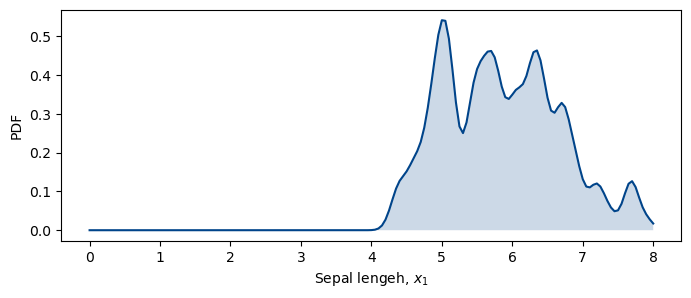

In [447]:
visualize(x1,f_x1,'#00448A') #可视化用的自定义函数 颜色为16进制颜色,在绘图中#表示16进制编码

In [449]:
color = ['#FF3300','#0099FF','#8A8A8A']

In [451]:
x1 = np.linspace(0,8,161)

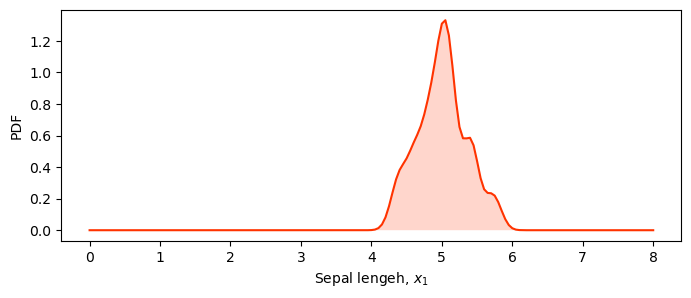

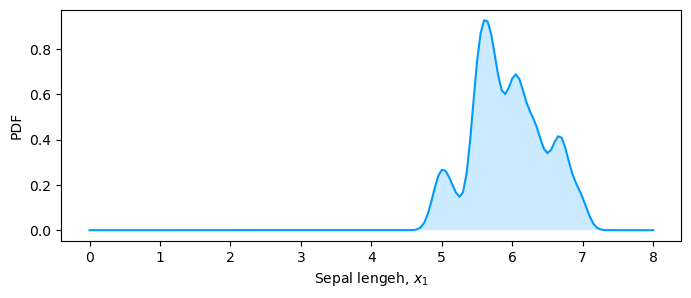

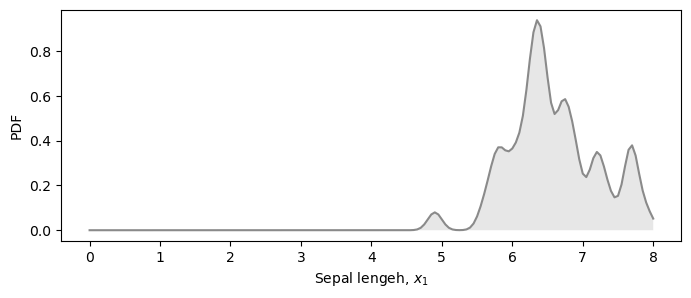

In [453]:
for idx in range(3):
    KDE_C_i = sm.nonparametric.KDEUnivariate(X1_df[y==idx])
    KDE_C_i.fit(bw = 0.1)
    f_x1_given_C_i = KDE_C_i.evaluate(x1)

    visualize(x1,f_x1_given_C_i,color[idx])

In [497]:
import matplotlib.pyplot as plt

In [499]:
def plot_surface(xx1,xx2,surface,x1_s,x2_s,
                 z_height,color,title_txt):
    fig = plt.figure(figsize = (8,3))#创建指定尺寸的空画布

    ax = fig.add_subplot(1,2,1,projection = '3d')
    #surface为高度值, sctride rstride为列步长行步长(控制稀疏程度) xy上的稀疏程度,z自动变化
    ax.plot_wireframe(xx1,xx2,surface,cstride = 8,rstride = 8,
                        color = [0.7,0.7,0.7],linewidth = 0.25)
    ax.scatter(x1_s,x2_s,x2_s*0,c = color)
    ax.contour(xx1,xx2,surface,20,cmap = 'RdYlBu_r')

    ax.set_proj_type('ortho')
    ax.set_xlabel('Sepal length, $x_1$')
    ax.set_ylabel('Sepal width,$x_2$')
    ax.set_zlabel('PDF')
    ax.set_xticks([]);ax.set_yticks([]);ax.set_zticks([])
    ax.set_xlim(x1.min(),x1.max())
    ax.set_ylim(x2.min(),x2.max())
    ax.set_zlim([0,z_height])#可为[]参数也可以为上面的两个参数的形式
    ax.view_init(azim=-120,elev=30)
    ax.set_title(title_txt)
    ax.grid(False)

    ax = fig.add_subplot(1,2,2)
    ax.contourf(xx1,xx2,surface,12,cmap = 'RdYlBu_r')
    ax.contour(xx1,xx2,surface,10,colors = 'w')
    ax.set_xticks([]);ax.set_yticks([])
    ax.set_xlim(x1.min(),x1.max())
    ax.set_ylim(x2.min(),x2.max())
    ax.set_xlabel('Sepal length,$x_1$')
    ax.set_ylabel('Sepal width,$x_2$')
    ax.set_aspect('equal',adjustable = 'box')
    ax.set_title(title_txt)

In [501]:
import numpy as np
import statsmodels.api as sm
import pandas as pd
from sklearn.datasets import load_iris
import scipy.stats as st

In [517]:
iris = load_iris()
X_1_to_4 = iris.data
#这里y为提取种类编号,是每个样本的分类标签数组
#是一维数组 每一个对应一行
y = iris.target

In [505]:
feature_names = ['Sepal length, $X_1$','Sepal width,$X_2$',
                 'Peatl length, $X_3$','Petal width,$X_4$']
#转为pd格式,方便切片
X_df = pd.DataFrame(X_1_to_4)
#取前两列
X1_2_df = X_df.iloc[:,[0,1]]

In [507]:
x1 = np.linspace(4,8,161);x2 = np.linspace(1,5,161)
xx1,xx2 = np.meshgrid(x1,x2)
#ravel展开为1维数组 vstack再将两个一维数组按垂直方向堆叠 v是vertical表示垂直
positions = np.vstack([xx1.ravel(),xx2.ravel()])
colors = ['#FF3300','#0099FF','#8A8A8A']

In [509]:
#根据样本数据估计概率密度曲线
KDE = st.gaussian_kde(X1_2_df.values.T)
#前面的positions的堆叠是为了表示x1,x2的对应,是KDE的点输入格式
#.T作用再KDE()上,是KDE运算后的  是习惯写法 对一维数组没效果,如果为二维1行n列变为n列1行方便reshape,确保reshape方向对
#先用KDE对象估计坐标网络positions然后将结果调整为xx1一样形状便于可视化
f_x1_x2 = np.reshape(KDE(positions).T,xx1.shape)

In [511]:
x1_s = X1_2_df.iloc[:,0] #依照索引提取
x2_s = X1_2_df.iloc[:,1]

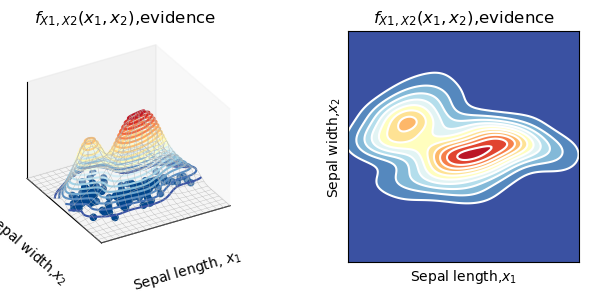

In [513]:
z_height = 0.5
title_txt = '$f_{X1,X2}(x_1,x_2)$,evidence'
plot_surface(xx1,xx2,f_x1_x2,
             x1_s,x2_s,z_height,
             '#00448A',title_txt)

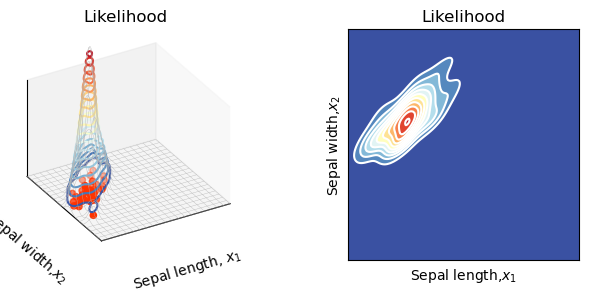

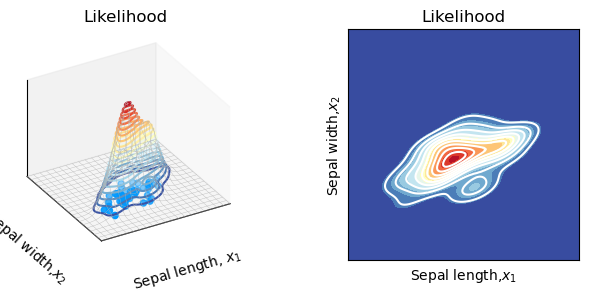

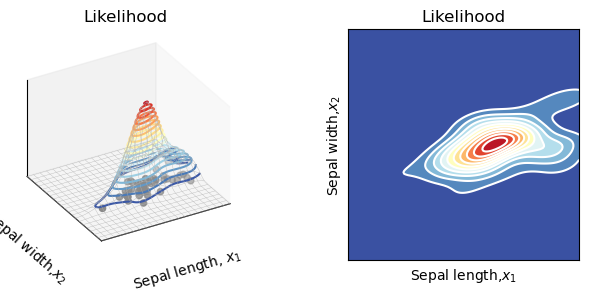

In [519]:
for idx in range(3):
    #利用[y==idx]的布尔数组提取值
    #一维数组的布尔列表自动按照行进行取值
    #使用.values转换成Numpy数组,.T表示转换为一列特征
    #仅仅建模
    KDE_idx = st.gaussian_kde(X1_2_df[y==idx].values.T)
    f_x1_x2_given_C_i = np.reshape(KDE_idx(positions).T,xx1.shape)

    x1_s_C_i = X1_2_df.iloc[:,0][y==idx]
    x2_s_C_i = X1_2_df.iloc[:,1][y==idx]

    z_height = 1
    title_txt = 'Likelihood'
    plot_surface(xx1,xx2,f_x1_x2_given_C_i,
                x1_s_C_i,x2_s_C_i,z_height,
                colors[idx],title_txt)